# 11i — Net-zero stock-level results

Stock-level decarbonization tracking-error results: re-solving a
tracking-error-minimization problem (extending the equity/bond
glide-path optimizations from `11h`) at real MSCI World stock level, at
every point along **four** decarbonization-pathway glide paths (IEA,
NZAOA, CTB, PAB, from `11f`'s `pathway_benchmarks()`) simultaneously,
for each of 4 emission scopes ($\mathcal{SC}_1,\mathcal{SC}_{1-2},
\mathcal{SC}^{up}_{1-3},\mathcal{SC}_{1-3}$). **The compute step itself
is not reproduced here**: it needs a stock-level holdings/emissions
dataset and a precomputed pathway-target file, neither of which is
available.

Two related results, however, are pure plotting outputs built from
**precomputed** result files (`chap11_net_zero10a.mat` and
`chap11_net_zero10c.mat`) that are available -- copied into this repo's
`data/` folder and built faithfully below. There is no way to
reconstruct what produced `chap11_net_zero10c.mat` (its `all_results`
array, and what its 7 entries individually represent, can't be
determined from usage alone -- only entry 6 of 7 is ever read); it's
used here as an opaque precomputed input.


In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


def packr(x, y):
    # Drop any (x, y) pair where either is NaN.
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    return x[mask], y[mask]


def smoothing_spline_curve(x_fit, y_fit, x_grid, p, scale=1.0, s=None, s_scale=0.1):
    # Fits a smoothing spline through (x_fit, y_fit) and evaluates it on
    # x_grid, masking beyond the fitted range. Uses scipy's
    # UnivariateSpline (in place of the third-party csaps package).
    # csaps's `p` (its `smooth` argument, in [0, 1] with 1 = pure
    # interpolation) and UnivariateSpline's `s` follow roughly inverse
    # conventions (p -> 1 corresponds to s -> 0), so unless an explicit
    # `s` is supplied we derive one from `p` and the data being fitted:
    # s = s_scale * n * var(y_fit) * (1 - p). This keeps p=1 exactly
    # interpolating (s=0) and scales the smoothing target with each
    # series' own variance, so callers can keep passing the same p
    # values used with csaps.
    x_fit, y_fit = packr(x_fit, y_fit)
    x_grid = np.asarray(x_grid, dtype=float)
    if s is None:
        s = max(s_scale * len(x_fit) * np.var(y_fit) * (1 - p), 0.0)
    spline = UnivariateSpline(x_fit, y_fit, k=3, s=s)
    y = scale * spline(x_grid)
    y = np.where(x_grid > x_fit[-1], np.nan, y)
    return y


PATHWAY_LABELS = ["IEA", "NZAOA", "CTB", "PAB"]
PATHWAY_COLORS = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
PATHWAY_STYLES = ["-", "--", ":", "-."]
SCOPE_TITLES = [r"$\mathcal{SC}_1$", r"$\mathcal{SC}_{1-2}$",
                r"$\mathcal{SC}^{up}_{1-3}$", r"$\mathcal{SC}_{1-3}$"]


def plot_scope_grid(x, y_by_scope, ylabel, ylims):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, y, title, ylim in zip(axes.flat, y_by_scope, SCOPE_TITLES, ylims):
        for i in range(4):
            ax.plot(x, y[:, i], PATHWAY_STYLES[i], color=PATHWAY_COLORS[i],
                     lw=2, label=PATHWAY_LABELS[i])
        ax.set_xlim(2020, 2035)
        ax.set_xticks(range(2020, 2036, 5))
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.set_xlabel("$t$")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    axes.flat[-1].legend(labels=PATHWAY_LABELS[::-1], handles=axes.flat[-1].get_lines()[::-1],
                          fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()

## 1. Tracking error vs. time, by scope

$\sigma(w\mid b)$ (bps) along each of the 4 pathway glide paths, for each
of the 4 emission scopes -- fit with a genuine smoothing spline
($p=1-\text{tol}=0.9$, not the near-interpolating case used in `11e`)
through the 30 yearly stock-level re-optimization points (2021-2050),
evaluated on a fine 0.1-year grid and masked (NaN) beyond the last point
each scope/pathway pair actually reached before the optimizer hit
infeasibility, visible here as `NaN`s in the raw data itself for the
higher scopes.


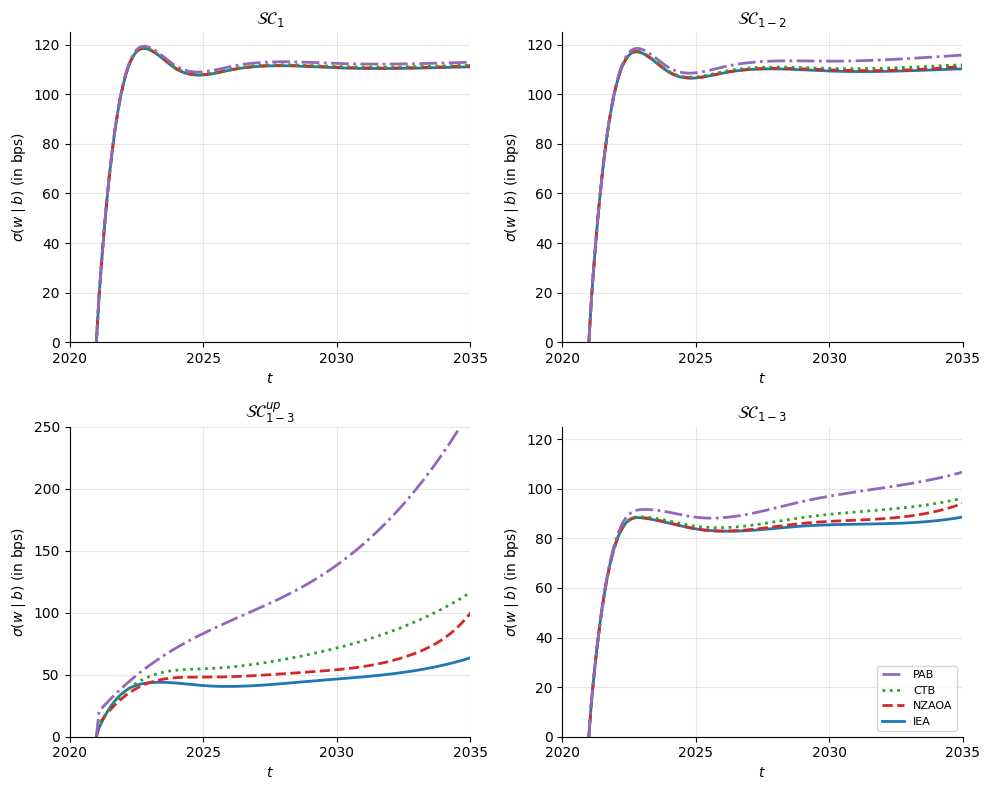

In [2]:
mat10a = sio.loadmat(f"{DATA_DIR}/chap11_net_zero10a.mat")
data_t = mat10a["all_t"].ravel().astype(float)
data_Risk = mat10a["all_sigma_x"]  # (nT=30, nPathway=4, nScope=4)

x_grid = np.arange(2021, 2050 + 1e-9, 0.1)
tol = 1e-1

y_by_scope_10b = []
for scope in range(4):
    data_Risk_Scope = data_Risk[:, :, scope]  # (nT, nPathway)
    y = np.zeros((len(x_grid), 4))
    for iter_ in range(4):
        y[:, iter_] = smoothing_spline_curve(data_t, data_Risk_Scope[:, iter_], x_grid,
                                              p=1 - tol, scale=1e4)
    y[0, :] = 0.0
    y_by_scope_10b.append(y)

plot_scope_grid(x_grid, y_by_scope_10b, r"$\sigma(w\mid b)$ (in bps)",
                 ylims=[(0, 125), (0, 125), (0, 250), (0, 125)])

## 2. A second stock-level risk metric vs. time, by scope

Same 4-scope grid, this time reading the precomputed
`chap11_net_zero10c.mat` file's `all_results(6)` entry directly (index 5
in 0-based Python) -- the file holds 7 unlabeled entries and this is
simply the one used here, with no further documentation of what
distinguishes the other six. Values are scaled by 100 and halved
(`y = y/2`), with no further explanation of the metric beyond its axis
label $\mathcal{D}(w\mid b)$ -- reproduced literally rather than guessed
at.


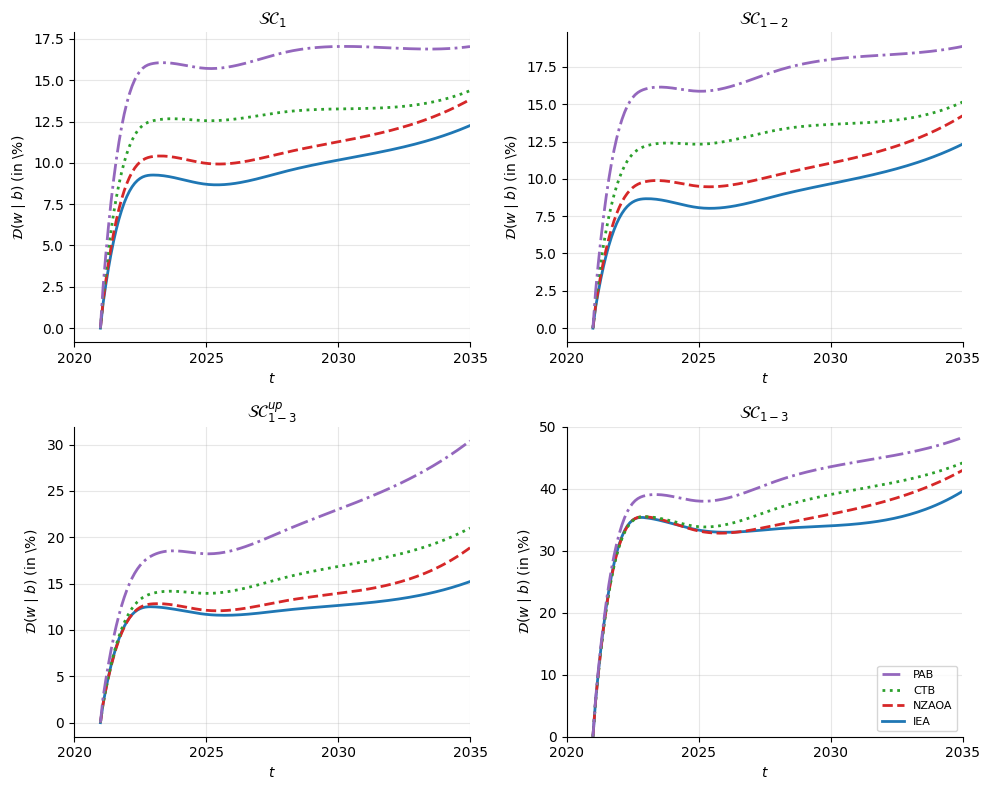

In [3]:
mat10c = sio.loadmat(f"{DATA_DIR}/chap11_net_zero10c.mat", struct_as_record=False, squeeze_me=True)
all_results = mat10c["all_results"]
entry = all_results[5]  # entry 6 of 7 (1-indexed)
data_t_c = entry.dates[:, 0, 0].astype(float)
data_D = entry.data  # (nT=15, nScope=4, nPathway=4)

y_by_scope_10c = []
for scope in range(4):
    data_D_Scope = data_D[:, scope, :]  # (nT, nPathway)
    y = np.zeros((len(x_grid), 4))
    for iter_ in range(4):
        y[:, iter_] = smoothing_spline_curve(data_t_c, data_D_Scope[:, iter_], x_grid,
                                              p=1 - tol, scale=100.0)
    y[0, :] = 0.0
    y = y / 2
    y_by_scope_10c.append(y)

plot_scope_grid(x_grid, y_by_scope_10c, r"$\mathcal{D}(w\mid b)$ (in \%)",
                 ylims=[None, None, None, (0, 50)])

## What's not computed here

The stock-level re-optimization itself -- the actual tracking-error
minimization at real MSCI World stock level, along all four pathway
glide paths and all four emission scopes -- is not reproduced in this
notebook. It requires two inputs that aren't available: a stock-level
MSCI World holdings/emissions panel, and a precomputed pathway-target
file feeding the glide-path grid. The precomputed `chap11_net_zero10a.mat`
output used in the section above shows that this compute step has been
run successfully at some point against the underlying data, but the raw
inputs needed to reproduce it here aren't available.

Similarly, whatever produced the `chap11_net_zero10c.mat` file's
`all_results` array (a set of 7 unlabeled entries) isn't available
either -- only the precomputed output and the plot built from it above
are reproducible here.
